# Chapter 16 — Sensor Calibration and Maintenance: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks listed in the book chapter. All exercises run entirely
> in the browser — no physical hardware is required. Every exercise uses
> a fixed random seed, so re-running the notebook reproduces exactly the
> numbers and figures shown in the book.

**Exercises in this notebook:**
1. **16.1** — Multi-Point Calibration of a Load-Cell Weight Sensor (with independent held-out validation)
2. **16.2** — Sensor Drift and the Cost-Optimal Recalibration Interval
3. **16.3** — Remote Fleet Calibration and Collaborative Fault Detection
4. **16.4** — Vibration-Based Predictive Maintenance and Remaining Useful Life


---
## Setup


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})
print("Environment ready")


Environment ready


---
## Exercise 16.1 — Multi-Point Calibration of a Load-Cell Weight Sensor

### Background

A calibration is only as good as its validation. A strain-gauge load cell
is close to linear over most of its range, but real devices carry
non-idealities a single-point calibration cannot see: a **zero offset**,
a **gain error**, a mild **nonlinearity**, and **hysteresis** (the reading
depends on whether the load was reached by loading or unloading).

This exercise builds a physically motivated load-cell simulator with all
four non-idealities, fits a multi-point calibration by **weighted** least
squares (weighting each calibration point by the inverse of its own
measured standard error), and — critically — evaluates the result on an
independent measurement set on a dense grid, drawn with fresh random noise
never seen during fitting (90 previously unseen loads, plus fresh repeated
measurements at the 11 calibration loads themselves). Reporting an
in-sample residual as if it were an accuracy figure is one of the most
common calibration mistakes in practice; this exercise is built
specifically to avoid it.

$$c(m, d) = c_0 + G \cdot m_{\text{eff}}(m, d) + k_{\text{nl}} \cdot m_{\text{eff}}(m, d)^2 + \varepsilon$$

where $d \in \{+1,-1\}$ is the loading direction and $m_{\text{eff}}$ adds a
hysteresis band that is zero at both ends of the range and largest at
mid-range.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})

# ── Exercise 16.1: Load-cell calibration model ─────────────────────────
class LoadCellSimulator:
    """Strain-gauge load cell with gain error, zero offset, mild
    quadratic nonlinearity, hysteresis (loading vs. unloading), and
    measurement noise. Output is in raw ADC counts; true_mass is in kg."""

    FULL_SCALE_KG = 50.0

    def __init__(self, gain=478.3, offset=812.0, nonlin_coeff=-0.024,
                 hysteresis_kg=0.35, noise_std=1.8):
        self.gain = gain
        self.offset = offset
        self.nonlin_coeff = nonlin_coeff
        self.hysteresis_kg = hysteresis_kg
        self.noise_std = noise_std

    def read(self, true_mass_kg, direction):
        """direction: +1 ascending (loading), -1 descending (unloading)."""
        span_frac = true_mass_kg / self.FULL_SCALE_KG
        hyst_shape = 4 * span_frac * (1 - span_frac)
        hyst_kg = direction * self.hysteresis_kg * hyst_shape / 2
        effective_mass = true_mass_kg + hyst_kg
        nonlinear_term = self.nonlin_coeff * effective_mass**2
        counts = self.offset + self.gain * effective_mass + nonlinear_term
        counts += np.random.normal(0, self.noise_std)
        return counts


cell = LoadCellSimulator()

# ── Calibration procedure: ascending + descending reference masses ─────
cal_masses = np.linspace(0, 50, 11)
N_REPEATS = 5

asc_readings = np.array([[cell.read(m, +1) for _ in range(N_REPEATS)]
                          for m in cal_masses])
desc_readings = np.array([[cell.read(m, -1) for _ in range(N_REPEATS)]
                           for m in cal_masses[::-1]])[::-1]

asc_mean = asc_readings.mean(axis=1)
desc_mean = desc_readings.mean(axis=1)
asc_std = asc_readings.std(axis=1, ddof=1)
desc_std = desc_readings.std(axis=1, ddof=1)

hysteresis_counts = np.abs(asc_mean - desc_mean)
hysteresis_kg_est = hysteresis_counts / cell.gain

# Combined standard error of the direction-averaged mean at each point,
# used as inverse-variance weights for the weighted least-squares fit
# (GUM-style propagation: averaging two independent direction means
# halves the variance again on top of the per-direction repeat average).
mean_readings = (asc_mean + desc_mean) / 2
combined_var = (asc_std**2 + desc_std**2) / 2
se_mean = np.sqrt(combined_var / (2 * N_REPEATS))
se_mean = np.maximum(se_mean, 1e-6)          # guard against zero-noise edge case
wls_weights = 1.0 / se_mean                   # numpy polyfit convention: w = 1/sigma

# ── Weighted least-squares calibration fits (2-point / 5-point / 11-point) ──
def fit_poly_weighted(true_mass, readings, degree, weights):
    return np.polyfit(readings, true_mass, degree, w=weights)

def apply_poly(readings, coeffs):
    return np.polyval(coeffs, readings)

idx_2pt = np.array([0, 10])
idx_5pt = np.array([0, 2, 5, 8, 10])
idx_11pt = np.arange(11)

coeffs_2pt = fit_poly_weighted(cal_masses[idx_2pt], mean_readings[idx_2pt], 1, wls_weights[idx_2pt])
coeffs_5pt = fit_poly_weighted(cal_masses[idx_5pt], mean_readings[idx_5pt], 2, wls_weights[idx_5pt])
coeffs_11pt = fit_poly_weighted(cal_masses[idx_11pt], mean_readings[idx_11pt], 2, wls_weights[idx_11pt])

# ── In-sample residuals (for reference only — NOT reported as accuracy) ──
insample_resid_11pt = apply_poly(mean_readings, coeffs_11pt) - cal_masses

# ── Independent held-out validation on a dense grid with FRESH readings ──
# 101 masses spanning the full range; each read once per direction with
# NEW random draws (continuing the RNG stream), never used for fitting.
val_masses = np.linspace(0, 50, 101)
val_asc = np.array([cell.read(m, +1) for m in val_masses])
val_desc = np.array([cell.read(m, -1) for m in val_masses])
val_mean_readings = (val_asc + val_desc) / 2

def validation_residuals(coeffs):
    pred = apply_poly(val_mean_readings, coeffs)
    return pred - val_masses

res_2pt_val = validation_residuals(coeffs_2pt)
res_5pt_val = validation_residuals(coeffs_5pt)
res_11pt_val = validation_residuals(coeffs_11pt)

# How much does weighting actually buy here? The simulator's ADC noise is
# close to homoscedastic across the range, so an ordinary (unweighted)
# least-squares fit is a fair comparison -- WLS is not automatically
# better just because it uses more information; it helps only to the
# extent that the per-point weights reflect a REAL difference in
# precision, and with only 5 repeats per point some of that apparent
# difference is itself sampling noise.
coeffs_11pt_ols = np.polyfit(mean_readings[idx_11pt], cal_masses[idx_11pt], 2)
res_11pt_val_ols = validation_residuals(coeffs_11pt_ols)
print(f"OLS (unweighted) 11-point fit: max held-out error {np.max(np.abs(res_11pt_val_ols)):.5f} kg, "
      f"RMS {np.sqrt(np.mean(res_11pt_val_ols**2)):.5f} kg")
print(f"WLS (weighted)   11-point fit: max held-out error {np.max(np.abs(res_11pt_val)):.5f} kg, "
      f"RMS {np.sqrt(np.mean(res_11pt_val**2)):.5f} kg")

# Single-direction field use: what if a field deployment reads only the
# ascending (or only the descending) direction, rather than averaging
# both, as the calibration and validation above both do? This isolates
# how much of the reported accuracy depends on that averaging protocol
# specifically cancelling hysteresis.
def validation_residuals_direction(coeffs, readings):
    pred = apply_poly(readings, coeffs)
    return pred - val_masses

res_11pt_val_asc_only = validation_residuals_direction(coeffs_11pt, val_asc)
res_11pt_val_desc_only = validation_residuals_direction(coeffs_11pt, val_desc)


OLS (unweighted) 11-point fit: max held-out error 0.00646 kg, RMS 0.00257 kg
WLS (weighted)   11-point fit: max held-out error 0.00622 kg, RMS 0.00258 kg


In [3]:
# ── Metrological parameters (validation-based, honestly labelled) ──────
max_validation_error_kg = np.max(np.abs(res_11pt_val))
rms_validation_error_kg = np.sqrt(np.mean(res_11pt_val**2))
repeatability_kg = np.sqrt(np.mean(np.concatenate([asc_std**2, desc_std**2]))) / cell.gain
noise_equivalent_mass_kg = (2 * cell.noise_std) / cell.gain
max_hysteresis_kg = np.max(hysteresis_kg_est)

print("=== Exercise 16.1 results ===")
print(f"11-point WLS calibration coefficients (highest degree first): {coeffs_11pt}")
print()
print(f"Max in-sample residual (11-pt fit, calibration data): "
      f"{np.max(np.abs(insample_resid_11pt)):.4f} kg  <- NOT a validity estimate")
print(f"Max HELD-OUT validation error (11-pt fit, 101-point independent grid): "
      f"{max_validation_error_kg:.4f} kg ({100*max_validation_error_kg/cell.FULL_SCALE_KG:.3f}% FS)")
print(f"RMS held-out validation error (11-pt fit): {rms_validation_error_kg:.4f} kg")
print()
print(f"Repeatability (precision), pooled 1-sigma: {repeatability_kg:.4f} kg")
print(f"Noise-equivalent mass (2x noise floor / gain): {noise_equivalent_mass_kg:.4f} kg")
print(f"Max hysteresis: {max_hysteresis_kg:.3f} kg ({100*max_hysteresis_kg/cell.FULL_SCALE_KG:.3f}% FS)")

print()
print(f"{'Calibration':<22s} {'Max held-out error':>20s} {'RMS held-out error':>20s}")
for label, res in [("2-point, linear", res_2pt_val), ("5-point, quadratic", res_5pt_val),
                    ("11-point, quadratic", res_11pt_val)]:
    print(f"{label:<22s} {np.max(np.abs(res)):20.4f} {np.sqrt(np.mean(res**2)):20.4f}")

print()
print("Single-direction field use (11-point calibration, same fitted model):")
print(f"{'Direction-averaged (as calibrated)':<38s} max={np.max(np.abs(res_11pt_val)):.4f} kg  "
      f"RMS={np.sqrt(np.mean(res_11pt_val**2)):.4f} kg")
print(f"{'Ascending-only reading':<38s} max={np.max(np.abs(res_11pt_val_asc_only)):.4f} kg  "
      f"RMS={np.sqrt(np.mean(res_11pt_val_asc_only**2)):.4f} kg")
print(f"{'Descending-only reading':<38s} max={np.max(np.abs(res_11pt_val_desc_only)):.4f} kg  "
      f"RMS={np.sqrt(np.mean(res_11pt_val_desc_only**2)):.4f} kg")


=== Exercise 16.1 results ===
11-point WLS calibration coefficients (highest degree first): [ 2.08274566e-10  2.09068812e-03 -1.69845615e+00]

Max in-sample residual (11-pt fit, calibration data): 0.0016 kg  <- NOT a validity estimate
Max HELD-OUT validation error (11-pt fit, 101-point independent grid): 0.0062 kg (0.012% FS)
RMS held-out validation error (11-pt fit): 0.0026 kg

Repeatability (precision), pooled 1-sigma: 0.0034 kg
Noise-equivalent mass (2x noise floor / gain): 0.0075 kg
Max hysteresis: 0.348 kg (0.695% FS)

Calibration              Max held-out error   RMS held-out error
2-point, linear                      0.0337               0.0218
5-point, quadratic                   0.0061               0.0026
11-point, quadratic                  0.0062               0.0026

Single-direction field use (11-point calibration, same fitted model):
Direction-averaged (as calibrated)     max=0.0062 kg  RMS=0.0026 kg
Ascending-only reading                 max=0.1820 kg  RMS=0.1281 kg
Des


Saved fig_16_1_loadcell_calibration.png


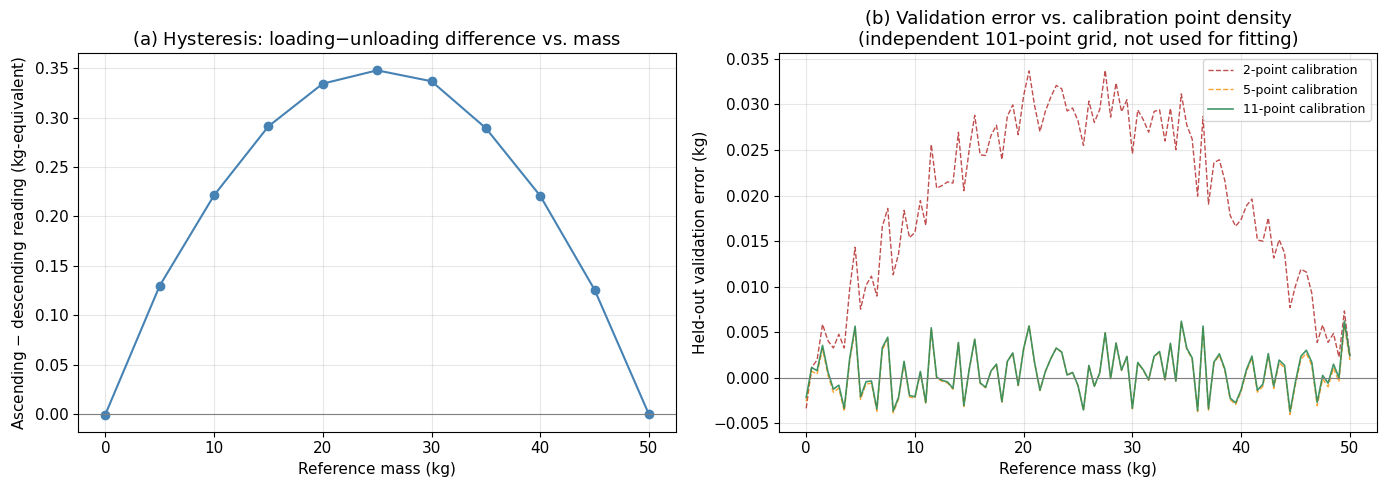

In [4]:
# ── Figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
diff_counts = asc_mean - desc_mean
diff_kg = diff_counts / cell.gain
ax.plot(cal_masses, diff_kg, 'o-', color='steelblue')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Reference mass (kg)')
ax.set_ylabel('Ascending $-$ descending reading (kg-equivalent)')
ax.set_title('(a) Hysteresis: loading$-$unloading difference vs. mass')

ax = axes[1]
ax.plot(val_masses, res_2pt_val, '--', color='firebrick', label='2-point calibration', alpha=0.8, lw=1)
ax.plot(val_masses, res_5pt_val, '--', color='darkorange', label='5-point calibration', alpha=0.8, lw=1)
ax.plot(val_masses, res_11pt_val, '-', color='seagreen', label='11-point calibration', alpha=0.9, lw=1.2)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Reference mass (kg)')
ax.set_ylabel('Held-out validation error (kg)')
ax.set_title('(b) Validation error vs. calibration point density\n(independent 101-point grid, not used for fitting)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_16_1_loadcell_calibration.png', dpi=150, bbox_inches='tight')
print("\nSaved fig_16_1_loadcell_calibration.png")


### Analysis

The hysteresis band (panel a) is zero at both 0 kg and 50 kg and peaks at
mid-range (**0.348 kg at 25 kg, i.e. 0.70% of full scale**) — the
tent-shaped pattern the hysteresis model was built to produce.

The held-out validation comparison (panel b) — evaluated on the independent
grid, under the same direction-averaged protocol used for calibration —
shows why validation matters: a 2-point linear calibration leaves a maximum
held-out error of **0.034 kg (0.067% FS)**, while a 5-point quadratic fit
already reduces that to **0.006 kg**, a ~6× improvement that going to 11
points does not meaningfully improve further. In this low-noise
simulation, once the model form is adequate, points beyond about five give
diminishing returns — an observation about *this* sensor and noise level,
not a universal rule (point placement, noise, and conditioning all matter
too). Note also that the 11-point fit's **in-sample** residual (0.002 kg)
is noticeably smaller than its own **held-out** validation error (0.006 kg)
— a real, measurable instance of the in-sample-vs-validation gap, even in
this well-behaved case.

**Is weighting actually doing anything here?** The simulator's ADC noise
is close to homoscedastic across the range, so this is *not* a case where
weighted least squares (WLS) is strongly physically motivated — with
weights estimated from only 5 repeats per point, some of the apparent
precision difference between points is itself sampling noise. And indeed:
unweighted OLS gives a held-out max error of **0.00646 kg** and RMS of
**0.00257 kg**, against WLS's **0.00622 kg** and **0.00258 kg** — WLS
edges out OLS on the max error and is negligibly worse on RMS. That's
practical equivalence, not a clear win for weighting. WLS would matter
far more for a sensor whose noise genuinely grows with load — see the
challenge tasks.

**Important caveat.** The 0.006 kg figure is a *direction-averaged* held-out
error, under the same bidirectional (load-then-unload-and-average) protocol
used for calibration. A field deployment that only ever reads one
direction sees a very different picture: **0.18 kg** (ascending-only) or
**0.19 kg** (descending-only) — more than 30× larger, almost entirely the
uncorrected hysteresis band, since hysteresis is not a function of mass
alone and no calibration curve fitted to direction-averaged data can
remove it from a single-direction reading.

**Key takeaway.** An accuracy figure is only as trustworthy as the data it
was evaluated on — and as the *measurement protocol* it was evaluated
under. Once the fitted calibration function can represent a sensor's
actual nonlinearity, a modest number of well-spaced points removes nearly
all systematic error in this simulation; a 2-point linear "shortcut" leaves
that nonlinearity completely uncorrected. Hysteresis is a separate error
source that direction-averaging manages but a single-direction field
reading does not. And a technique (WLS) can be implemented correctly and
still not clearly outperform the simpler alternative, if the physical
assumption behind it doesn't hold for the data at hand.

**Challenge tasks:** (1) Fit a cubic polynomial and check whether it helps
held-out error or just the in-sample residual. (2) Fit separate
ascending/descending calibration curves instead of averaging them. (3) Add
a temperature-dependent gain error and validate at a *different*
temperature than the one used for calibration. (4) Give the simulator
genuinely load-dependent noise (e.g. `noise_std * (1 + beta * mass/FS)`)
and repeat the OLS-vs-WLS comparison — how large does `beta` need to be
before WLS clearly and repeatably wins?


---
## Exercise 16.2 — Sensor Drift and the Cost-Optimal Recalibration Interval

### Background

A sensor's calibration decays over time: components age, optical windows
collect dust, reference offsets wander. A fleet of low-cost IoT sensors
will not all drift at the same rate, and nobody can recalibrate every
unit every week. This exercise asks: **given how a sensor actually
drifts, how often should the fleet be recalibrated, and what does getting
that interval wrong actually cost?**

Each unit's error combines a deterministic aging drift (rate $r_i =
\max(0, Z_i)$, $Z_i\sim\mathcal{N}(\mu_r,\sigma_r^2)$ — a **clipped**, not
truncated, normal) with a stochastic random-walk disturbance. The
recalibration interval is chosen two ways: a **reliability-target**
interval (the *largest* $T$ with $S(T)\geq$ target — not the first month
the target is breached) and a **cost-optimal** interval from the classical
age-replacement model of reliability engineering (Barlow & Hunter, 1960):

$$\text{Cost rate}(T) = \frac{C_p\,S(T) + C_f\,(1-S(T))}{\sum_{t=0}^{T-1} S(t)}$$


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})

# ── Exercise 16.2: Fleet drift model ────────────────────────────────────
N_UNITS = 500
N_MONTHS = 36
TOLERANCE_PPM = 100.0

MU_DRIFT = 15.0
SIGMA_DRIFT = 5.0
SIGMA_RW = 8.0

months = np.arange(0, N_MONTHS + 1)

# Aging-drift rate: r_i = max(0, Z_i), Z_i ~ N(mu, sigma^2). This is a
# clipped normal, not a truncated normal (clipping places a discrete
# probability mass at exactly zero, rather than renormalising the
# density over r >= 0); the distinction rarely matters numerically at
# these parameter values (mu = 3*sigma), but the two are not the same
# distribution and only the clipped version is what this code draws.
Z = np.random.normal(MU_DRIFT, SIGMA_DRIFT, size=N_UNITS)
drift_rate = np.maximum(0.0, Z)

rw_steps = np.random.normal(0, SIGMA_RW, size=(N_UNITS, N_MONTHS))
rw_path = np.hstack([np.zeros((N_UNITS, 1)), np.cumsum(rw_steps, axis=1)])
error_path = drift_rate[:, None] * months[None, :] + rw_path

# ── Time to first breach of tolerance for each unit ────────────────────
breached = np.abs(error_path) > TOLERANCE_PPM
first_breach_month = np.full(N_UNITS, np.nan)
for i in range(N_UNITS):
    idx = np.argmax(breached[i])
    if breached[i, idx]:
        first_breach_month[i] = months[idx]
censored = np.isnan(first_breach_month)
print(f"Units that breach tolerance within {N_MONTHS} months: "
      f"{(~censored).sum()} / {N_UNITS} ({100*(~censored).mean():.1f}%)")

# ── Empirical fleet-reliability curve S(t) ──────────────────────────────
survival = np.array([np.mean((first_breach_month > t) | censored) for t in months])

def max_interval_for_reliability(target):
    """Largest T such that S(T) >= target (the interval must GUARANTEE
    the reliability target is still met AT that interval, not merely
    the first month the target is breached)."""
    ok = np.where(survival >= target)[0]
    return months[ok[-1]] if len(ok) else 0

t95 = max_interval_for_reliability(0.95)
t90 = max_interval_for_reliability(0.90)
t50 = max_interval_for_reliability(0.50)
print(f"Recalibration interval for >=95% fleet reliability: {t95} months "
      f"(S({t95})={survival[t95]*100:.1f}%, S({t95+1})={survival[t95+1]*100:.1f}%)")
print(f"Recalibration interval for >=90% fleet reliability: {t90} months")
print(f"Recalibration interval for >=50% fleet reliability (median): {t50} months")

# ── Age-replacement cost model (Barlow & Hunter, 1960) ──────────────────
# Cost rate(T) = [C_p * S(T) + C_f * (1 - S(T))] / M(T), where M(T) is
# the expected cycle length, approximated here as the discrete sum
# sum_{t=0}^{T-1} S(t) (a left-Riemann approximation of integral_0^T S(t)dt
# over unit-month steps -- NOT sum_{t=0}^{T}, which would double-count
# one extra month of "fully reliable" time at every T).
C_P = 50.0
C_F = 500.0

T_grid = np.arange(1, N_MONTHS + 1)
R_at_T = survival[T_grid]
M_at_T = np.array([survival[:T].sum() for T in T_grid])   # sum over t=0..T-1
cost_rate = (C_P * R_at_T + C_F * (1 - R_at_T)) / M_at_T

T_star_idx = np.argmin(cost_rate)
T_star = T_grid[T_star_idx]
print(f"\nCost-optimal recalibration interval: {T_star} months "
      f"(cost rate {cost_rate[T_star_idx]:.2f} currency units/month)")
print(f"Fleet reliability at T*: {R_at_T[T_star_idx]*100:.1f}%")
print(f"{'T (months)':>10s} {'Cost rate':>12s}")
for T in [1, 2, 3, 4, 5, 6]:
    print(f"{T:10d} {cost_rate[T-1]:12.2f}")


Units that breach tolerance within 36 months: 494 / 500 (98.8%)
Recalibration interval for >=95% fleet reliability: 3 months (S(3)=99.6%, S(4)=94.2%)
Recalibration interval for >=90% fleet reliability: 4 months
Recalibration interval for >=50% fleet reliability (median): 6 months

Cost-optimal recalibration interval: 3 months (cost rate 17.27 currency units/month)
Fleet reliability at T*: 99.6%
T (months)    Cost rate
         1        50.00
         2        25.00
         3        17.27
         4        19.04
         5        28.72
         6        38.23



Saved fig_16_2_drift_recalibration.png


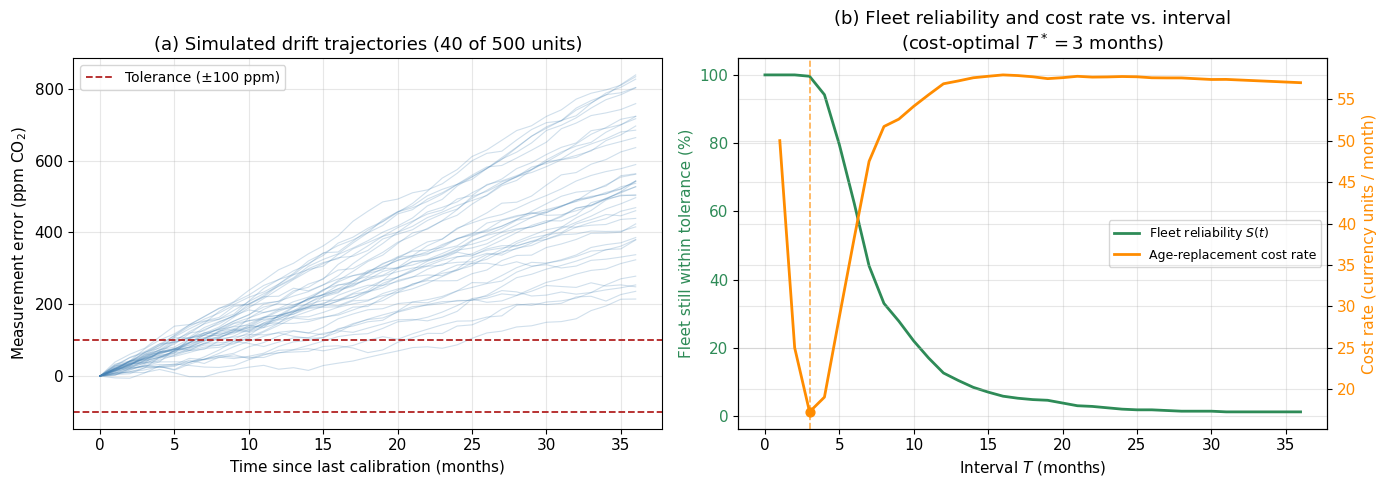

In [6]:
# ── Figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sample_idx = np.random.choice(N_UNITS, 40, replace=False)
for i in sample_idx:
    ax.plot(months, error_path[i], color='steelblue', alpha=0.25, lw=0.8)
ax.axhline(TOLERANCE_PPM, color='firebrick', ls='--', lw=1.3, label=f'Tolerance (\u00b1{TOLERANCE_PPM:.0f} ppm)')
ax.axhline(-TOLERANCE_PPM, color='firebrick', ls='--', lw=1.3)
ax.set_xlabel('Time since last calibration (months)')
ax.set_ylabel('Measurement error (ppm CO$_2$)')
ax.set_title('(a) Simulated drift trajectories (40 of 500 units)')
ax.legend()

ax2 = axes[1]
l1, = ax2.plot(months, survival * 100, color='seagreen', lw=2, label='Fleet reliability $S(t)$')
ax2.set_xlabel('Interval $T$ (months)')
ax2.set_ylabel('Fleet still within tolerance (%)', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

ax3 = ax2.twinx()
l2, = ax3.plot(T_grid, cost_rate, color='darkorange', lw=2, label='Age-replacement cost rate')
ax3.set_ylabel('Cost rate (currency units / month)', color='darkorange')
ax3.tick_params(axis='y', labelcolor='darkorange')
ax3.axvline(T_star, color='darkorange', ls='--', lw=1.2, alpha=0.7)
ax3.scatter([T_star], [cost_rate[T_star_idx]], color='darkorange', zorder=5, s=40)

ax2.set_title(f'(b) Fleet reliability and cost rate vs. interval\n(cost-optimal $T^*={T_star}$ months)')
ax2.legend(handles=[l1, l2], loc='center right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_16_2_drift_recalibration.png', dpi=150, bbox_inches='tight')
print("\nSaved fig_16_2_drift_recalibration.png")


### Analysis

By month 3, 99.6% of the fleet is still within tolerance; by month 4 that
has already fallen to 94.2%. The reliability-target interval for ≥95%
fleet reliability is therefore **3 months** — the *largest* interval for
which the target still holds, not the first month it's broken.

With $C_p=50$ and $C_f=500$, the cost-optimal interval is also **$T^*=3$
months** (cost rate 17.27 currency units/month) — in this case matching
the reliability target, though the two calculations answer different
questions and will not, in general, coincide. A shorter interval wastes
visits on units that were still fine; a longer interval saves visits but
pays for a fast-growing share of failure-cost events.

**Key takeaway.** A reliability-target interval must be the *largest*
interval that still meets the target — an easy off-by-one to get
backwards. The cost-optimal interval additionally weighs the relative
cost of a planned visit against an unplanned failure, and depends on the
*ratio* $C_f/C_p$, not either cost alone.

**Challenge tasks:** (1) Re-run with $C_f/C_p=3$ instead of 10. (2)
Implement a condition-based, per-unit alternative to the fixed schedule.
(3) Add a "noisy" sub-population with 2× the random-walk variance.


---
## Exercise 16.3 — Remote Fleet Calibration and Collaborative Fault Detection

### Background

A city-scale air-quality network cannot bring every low-cost PM$_{2.5}$
node to a reference instrument. This exercise fits a remote-calibration
model, $PM_{\text{cal}} = a\cdot PM_{\text{raw}} + b\cdot T + c\cdot RH +
d$, using only 3 reference-colocated nodes out of 10, transfers it
network-wide, and adds a **cross-sectional** (leave-one-out) robust
$z$-score to catch a node whose behaviour has diverged from its peers —
without needing a reference instrument *at the monitored node itself*
during online operation (the correction model it runs was, of course,
originally fitted using reference instruments elsewhere):

$$z_i(t)=\frac{y_i(t)-\text{median}_{j\neq i}(y_j(t))}{1.4826\cdot\text{MAD}_{j\neq i}(y_j(t))}$$

Unlike a detector that compares a node to its own recent history (which
re-centres on a new, faulty baseline and eventually stops alarming), a
cross-sectional comparison against the rest of the network has no such
blind spot. **Note the implicit assumption:** this only works if most
nodes are healthy and exposed to genuinely comparable conditions — a
real, spatially localised pollution event can look statistically
identical to a single faulty node.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})

# ── Exercise 16.3: Distributed low-cost PM2.5 network ───────────────────
N_NODES = 10
REF_NODES = [0, 1, 2]
FAULTY_NODE = 6
N_DAYS = 60
HOURS = N_DAYS * 24
CAL_DAYS = 14
CAL_HOURS = CAL_DAYS * 24
t = np.arange(HOURS)

diurnal = 6 * (1 + np.sin(2 * np.pi * (t % 24 - 7) / 24))
weekly = 4 * (((t // 24) % 7) < 5)
episodes = np.zeros(HOURS)
for center in [20 * 24, 33 * 24, 50 * 24]:
    width = 18
    episodes += 25 * np.exp(-0.5 * ((t - center) / width) ** 2)
regional_pm = np.clip(10 + diurnal + weekly + episodes, 2, None)

temperature = (18 + 8 * np.sin(2 * np.pi * (t - 9 * 24) / (24 * 60))
               + 4 * np.sin(2 * np.pi * (t - 8) / 24) + np.random.normal(0, 0.6, HOURS))
humidity = np.clip(55 + 15 * np.sin(2 * np.pi * (t - 3) / 24 + np.pi)
                    + np.random.normal(0, 3, HOURS), 20, 98)

local_offset = np.random.uniform(-2.5, 2.5, N_NODES)
gain = np.random.normal(0.80, 0.10, N_NODES)
offset = np.random.normal(3.0, 2.0, N_NODES)
HUMIDITY_COEFF = 0.18
TEMP_COEFF = -0.10
NOISE_STD = 2.0

true_pm = np.clip(regional_pm[None, :] + local_offset[:, None]
                   + np.random.normal(0, 1.0, (N_NODES, HOURS)), 1, None)

raw = (gain[:, None] * true_pm + offset[:, None]
       + HUMIDITY_COEFF * humidity[None, :] + TEMP_COEFF * temperature[None, :]
       + np.random.normal(0, NOISE_STD, (N_NODES, HOURS)))

FAULT_START_HOUR = 40 * 24
raw[FAULTY_NODE, FAULT_START_HOUR:] += 22.0

# ── Remote calibration: fit on reference nodes' calibration-period data ──
train_mask_time = np.arange(HOURS) < CAL_HOURS
X_rows, y_rows = [], []
for n in REF_NODES:
    X_rows.append(np.column_stack([raw[n, train_mask_time], temperature[train_mask_time],
                                    humidity[train_mask_time]]))
    y_rows.append(true_pm[n, train_mask_time])
X_train, y_train = np.vstack(X_rows), np.concatenate(y_rows)
X_design = np.column_stack([X_train, np.ones(len(X_train))])
a_fit, b_fit, c_fit, d_fit = np.linalg.lstsq(X_design, y_train, rcond=None)[0]
print("=== Exercise 16.3 results ===")
print(f"Fitted remote calibration model: PM_cal = {a_fit:.4f}*raw + {b_fit:.4f}*T "
      f"+ {c_fit:.4f}*RH + {d_fit:.4f}")

# Algebraic expectation from inverting the generative model at the mean
# generative gain (raw = g*PM + o + 0.18*RH - 0.10*T  =>
#                  PM  = (1/g)*raw - (o/g) - (0.18/g)*RH + (0.10/g)*T):
g_mean = gain[REF_NODES].mean()
print(f"Mean reference-node gain: {g_mean:.4f} -> expected single-node inverse "
      f"a~{1/g_mean:.4f}, b~{0.10/g_mean:+.4f}, c~{-0.18/g_mean:+.4f}")

# Collinearity diagnostics for the two environmental covariates over the
# calibration window (reported honestly rather than asserted):
corr_T_RH = np.corrcoef(temperature[train_mask_time], humidity[train_mask_time])[0, 1]
X_std = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
cond_number = np.linalg.cond(X_std)
print(f"Corr(T, RH) over calibration window: {corr_T_RH:.3f}")
print(f"Condition number of standardised design matrix: {cond_number:.3f}")

def calibrate(node_raw):
    return a_fit * node_raw + b_fit * temperature + c_fit * humidity + d_fit

calibrated = np.vstack([calibrate(raw[n]) for n in range(N_NODES)])

val_mask = ~train_mask_time
def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))

rmse_raw_list = [rmse(raw[n, val_mask], true_pm[n, val_mask]) for n in range(N_NODES)]
rmse_cal_list = [rmse(calibrated[n, val_mask], true_pm[n, val_mask]) for n in range(N_NODES)]

mean_rmse_raw_field = np.mean([rmse_raw_list[n] for n in range(N_NODES)
                                if n not in REF_NODES and n != FAULTY_NODE])
mean_rmse_cal_field = np.mean([rmse_cal_list[n] for n in range(N_NODES)
                                if n not in REF_NODES and n != FAULTY_NODE])
print(f"\nMean field-node RMSE: {mean_rmse_raw_field:.2f} -> {mean_rmse_cal_field:.2f} ug/m3 "
      f"({100*(1 - mean_rmse_cal_field/mean_rmse_raw_field):.1f}% reduction)")

print(f"\n{'Node':>5s} {'Type':>14s} {'RMSE raw':>10s} {'RMSE cal.':>10s} {'Improvement':>12s}")
for n in range(N_NODES):
    kind = 'reference' if n in REF_NODES else ('FAULTY' if n == FAULTY_NODE else 'field (remote)')
    print(f"{n:5d} {kind:>14s} {rmse_raw_list[n]:10.2f} {rmse_cal_list[n]:10.2f} "
          f"{100*(1 - rmse_cal_list[n]/rmse_raw_list[n]):11.1f}%")

# ── Collaborative anomaly detection: CROSS-SECTIONAL leave-one-out ─────
# At each hour, compare node i against the median/MAD of the OTHER nine
# nodes at that SAME hour (not against its own recent history). This
# persists for as long as a fault persists, unlike a temporal rolling
# window, which re-centres on the new (faulty) level within one window
# length and then stops alarming even though the fault never went away.
def cross_sectional_zscore(node_idx, values):
    others = np.delete(values, node_idx, axis=0)     # (N_NODES-1, HOURS)
    med = np.median(others, axis=0)
    mad = np.median(np.abs(others - med[None, :]), axis=0) * 1.4826 + 1e-6
    return (values[node_idx] - med) / mad

z_all = np.vstack([cross_sectional_zscore(n, calibrated) for n in range(N_NODES)])

ALARM_THRESHOLD = 5.0
z_faulty = z_all[FAULTY_NODE]
alarm_idx = np.where(np.abs(z_faulty) > ALARM_THRESHOLD)[0]
first_alarm_hour = alarm_idx[alarm_idx >= FAULT_START_HOUR][0] if np.any(alarm_idx >= FAULT_START_HOUR) else None
hours_after_fault_flagged = np.sum(np.abs(z_faulty[FAULT_START_HOUR:]) > ALARM_THRESHOLD)
total_hours_after_fault = HOURS - FAULT_START_HOUR
print(f"\nFault injected at hour {FAULT_START_HOUR} (day {FAULT_START_HOUR/24:.0f})")
print(f"First alarm at hour {first_alarm_hour} (day {first_alarm_hour/24:.2f})" if first_alarm_hour is not None
      else "No alarm raised")
print(f"Fraction of post-fault hours flagged (persistence check): "
      f"{hours_after_fault_flagged}/{total_hours_after_fault} "
      f"({100*hours_after_fault_flagged/total_hours_after_fault:.1f}%)")

# False-alarm rate across ALL nine non-faulty nodes (not just one)
healthy_nodes = [n for n in range(N_NODES) if n != FAULTY_NODE]
false_alarm_counts = {n: int(np.sum(np.abs(z_all[n]) > ALARM_THRESHOLD)) for n in healthy_nodes}
total_false_alarms = sum(false_alarm_counts.values())
total_healthy_hours = len(healthy_nodes) * HOURS
print(f"False alarms across all {len(healthy_nodes)} non-faulty nodes: "
      f"{total_false_alarms} / {total_healthy_hours} node-hours "
      f"({100*total_false_alarms/total_healthy_hours:.3f}% raw pointwise rate)")
print(f"Operationally: {total_false_alarms} false alarms over {N_DAYS} days "
      f"= {total_false_alarms/N_DAYS:.2f} false node-alarms/day, network-wide")


=== Exercise 16.3 results ===
Fitted remote calibration model: PM_cal = 0.8924*raw + 0.2154*T + -0.2039*RH + 1.7300
Mean reference-node gain: 0.7961 -> expected single-node inverse a~1.2562, b~+0.1256, c~-0.2261
Corr(T, RH) over calibration window: -0.167
Condition number of standardised design matrix: 1.416

Mean field-node RMSE: 7.76 -> 4.11 ug/m3 (46.9% reduction)

 Node           Type   RMSE raw  RMSE cal.  Improvement
    0      reference       9.58       2.37        75.3%
    1      reference       8.87       3.23        63.6%
    2      reference       8.43       3.30        60.9%
    3 field (remote)       6.63       3.60        45.8%
    4 field (remote)       8.67       2.87        66.8%
    5 field (remote)      10.59       2.59        75.6%
    6         FAULTY      20.14      11.59        42.4%
    7 field (remote)       4.91       7.59       -54.5%
    8 field (remote)       8.03       3.43        57.3%
    9 field (remote)       7.70       4.61        40.1%

Fault inject


Saved fig_16_3_collaborative_calibration.png


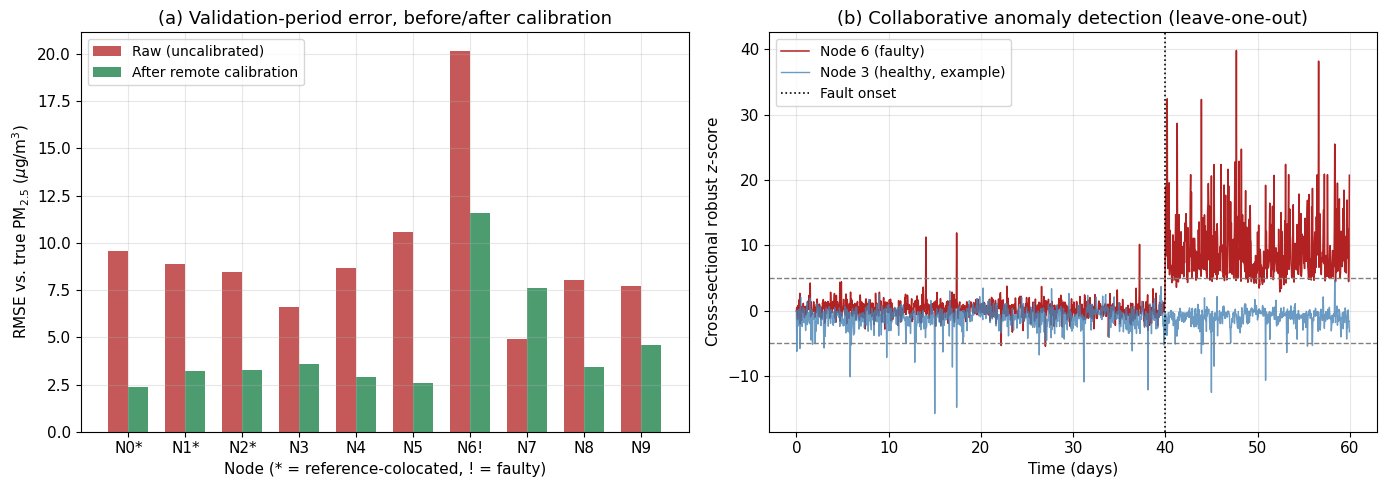

In [8]:
# ── Figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
node_labels = [f"N{n}" + ("*" if n in REF_NODES else ("!" if n == FAULTY_NODE else ""))
               for n in range(N_NODES)]
x = np.arange(N_NODES)
w = 0.35
ax.bar(x - w/2, rmse_raw_list, width=w, color='firebrick', alpha=0.75, label='Raw (uncalibrated)')
ax.bar(x + w/2, rmse_cal_list, width=w, color='seagreen', alpha=0.85, label='After remote calibration')
ax.set_xticks(x); ax.set_xticklabels(node_labels)
ax.set_xlabel('Node (* = reference-colocated, ! = faulty)')
ax.set_ylabel('RMSE vs. true PM$_{2.5}$ ($\\mu$g/m$^3$)')
ax.set_title('(a) Validation-period error, before/after calibration')
ax.legend()

ax = axes[1]
days = t / 24
ax.plot(days, z_faulty, color='firebrick', lw=1.1, label=f'Node {FAULTY_NODE} (faulty)')
ax.plot(days, z_all[3], color='steelblue', lw=1.0, alpha=0.8, label='Node 3 (healthy, example)')
ax.axhline(ALARM_THRESHOLD, color='gray', ls='--', lw=1)
ax.axhline(-ALARM_THRESHOLD, color='gray', ls='--', lw=1)
ax.axvline(FAULT_START_HOUR / 24, color='black', ls=':', lw=1.2, label='Fault onset')
ax.set_xlabel('Time (days)'); ax.set_ylabel('Cross-sectional robust $z$-score')
ax.set_title('(b) Collaborative anomaly detection (leave-one-out)')
ax.legend()

plt.tight_layout()
plt.savefig('fig_16_3_collaborative_calibration.png', dpi=150, bbox_inches='tight')
print("\nSaved fig_16_3_collaborative_calibration.png")


### Analysis

The fitted model reduces mean RMSE of the **six healthy** non-reference
field nodes (N3, N4, N5, N7, N8, N9 — deliberately excluding faulty N6)
from 7.76 to **4.11 µg/m³** (46.9% reduction) using zero reference
instruments at those locations. The fitted coefficients ($b=+0.215$,
$c=-0.204$) have the signs the algebraically correct **inverse** of the
generative relationship predicts (temperature positive, humidity
negative) — checking against the correct reference frame matters, since
comparing them naively to the forward-model coefficients would suggest
something is wrong when it isn't. The gap in magnitude versus a
single-node theoretical inverse reflects pooling across nodes with
different individual gains/offsets (correlation between T and RH over
the calibration window is only −0.17, condition number 1.42 — not
meaningful collinearity).

Node N7 is the one exception: its raw RMSE was already best by chance,
and the pooled calibration made it *worse* (+54.5%) — remote calibration
helps on average, not for every node individually.

The cross-sectional detector flags node N6's fault the same hour it's
injected and **remains persistently elevated afterward**: 90% of
post-fault hours are flagged (not every single hour — noise still
occasionally brings an individual reading back under threshold, but the
fault keeps being re-flagged rather than fading out). The corresponding
false-alarm rate, measured across all 9 healthy nodes, is 1.3% of
individual hourly readings — a raw, pointwise rate that still amounts to
roughly 3 false node-alarms per day network-wide, which an operational
deployment would want to suppress with a persistence rule (e.g. 3-of-4
readings) before treating a single flagged hour as actionable.

**Key takeaway.** Remote calibration is a network-level improvement, not
a per-node guarantee. Check a transferred model's coefficients against
the correct (often inverted) physical reference frame. Cross-sectional
comparison detects a persistent fault that a temporal comparison cannot
— though a raw pointwise false-alarm rate still needs a persistence rule
before it's operationally deployable, and the detector itself rests on a
spatial-consistency assumption (most nodes healthy, comparable
conditions) that a genuine local pollution event can violate the same
way a genuine fault would.

**Challenge tasks:** (1) Replace the abrupt fault with a slow 20-day
drift. (2) Fit a separate model per reference node instead of pooling.
(3) Verify the detector does *not* false-alarm during the built-in
city-wide pollution episodes.


---
## Exercise 16.4 — Vibration-Based Predictive Maintenance and Remaining Useful Life

### Background

This final exercise turns the sensor around: instead of correcting its
readings, it uses vibration to monitor the **equipment** it's mounted on.
A degrading bearing grows in overall vibration amplitude and develops
harmonic content well before it seizes. The growth-rate constant is a
**simulator design parameter** (chosen so synthetic degradation reaches
failure around week 45); the fitting procedure never receives it.

Three design choices keep this exercise honest: (1) the **failure
threshold** (1.70 g) is fixed *a priori* — an *illustrative* simulation
value, not a number taken from a specific ISO 20816 clause; (2) **a
single baseline RMS is estimated once**, from three independent healthy
snapshots taken *at week 0*, and that **same** baseline is used to define
the health index for *both* the observed data and the hidden reference
trajectory below — using two different baselines for the two curves would
make the one threshold mean two different things depending which curve it
was checked against, an easy trap to fall into by estimating each curve's
"natural" baseline separately; (3) the **reference failure week** is read
off a *noise-averaged hidden reference trajectory* — 60 independent
realisations averaged at every week, using seeds unrelated to the 31-week
history the fitting procedure sees, expressed relative to that same
shared baseline — as the first week it crosses the threshold. The
reference failure week is necessarily *derived from* the threshold
(failure only means something relative to a severity limit); what's
independent is the hidden reference trajectory versus the single noisy
31-week realisation given to the estimator.

With the shared baseline, $HI(0)$ is very close to, but not mechanically
forced to, zero — which still rules out fitting $HI(w)\approx Ae^{kw}$
(forces $HI(0)=A>0$, a structural contradiction). Instead we fit
$HI(w) \approx A(e^{kw}-1)$, exactly zero at $w=0$ for any $A,k$, by
nonlinear least squares (bounding $A,k\geq 0$). A genuine, **centered**
residual bootstrap gives the confidence interval — but that assumes the
residuals are approximately *exchangeable*, which the Analysis below
checks rather than assumes.


In [9]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})

# ── Exercise 16.4: Vibration-based predictive maintenance ──────────────
FS = 5000
SNAP_DURATION = 0.5
N_SNAP = int(FS * SNAP_DURATION)
F0 = 50.0
A0 = 1.0

OBSERVE_UP_TO_WEEK = 30

# The growth-rate constant below is a SIMULATOR DESIGN PARAMETER: it sets
# the timescale over which the synthetic degradation unfolds (chosen here
# to reach the failure level at approximately week 45), not a value
# derived from any external physical process. The fitting procedure never
# receives this constant or the week-45 target directly -- it only ever
# sees the 31 noisy weekly snapshots generated from it. -------------------
GROWTH_RATE = np.log(1.0 / 0.02) / 45.0

def fault_level(week):
    return 0.02 * np.exp(GROWTH_RATE * week)

def simulate_snapshot(week, seed):
    rng = np.random.default_rng(seed)
    fl = fault_level(week)
    tt = np.arange(N_SNAP) / FS
    amp_scale = 1 + 2.2 * fl
    sig = A0 * amp_scale * np.sin(2 * np.pi * F0 * tt)
    sig += A0 * 0.35 * fl * np.sin(2 * np.pi * 2 * F0 * tt + 0.6)
    sig += A0 * 0.22 * fl * np.sin(2 * np.pi * 3 * F0 * tt + 1.1)
    n_impulses = rng.poisson(0.5 + 8 * fl)
    for _ in range(n_impulses):
        center = rng.integers(0, N_SNAP)
        width = 6
        idx = np.arange(max(0, center - 20), min(N_SNAP, center + 20))
        sig[idx] += (1.5 + 3 * fl) * rng.normal(1, 0.2) * np.exp(-0.5 * ((idx - center) / width) ** 2)
    sig += rng.normal(0, 0.08, N_SNAP)
    return tt, sig

# ── Step 1: an a-priori failure threshold, fixed BEFORE looking at any
# specific trajectory. Illustrative simulation value, not read from a
# specific ISO 20816 clause. -----------------------------------------------
HI_THRESHOLD = 1.70   # g

# ── Step 2: a SINGLE, shared baseline, estimated from three independent
# healthy snapshots taken AT WEEK 0 (a short commissioning-time
# calibration campaign), using seeds unrelated to every other snapshot
# generated below. This one baseline value is then used to define the
# health index for BOTH the observed data (Step 3) and the hidden
# reference trajectory (Step 4) -- applying two different baselines to
# data compared against the same threshold would make that threshold
# mean two different things depending which curve it was applied to. ----
BASELINE_SEEDS = [900_001, 900_002, 900_003]
baseline_rms = np.mean([np.sqrt(np.mean(simulate_snapshot(0, seed)[1] ** 2)) for seed in BASELINE_SEEDS])
print("=== Exercise 16.4 results ===")
print(f"Shared baseline RMS (mean of 3 independent week-0 snapshots): {baseline_rms:.5f} g")
print(f"A-priori failure threshold (illustrative, not a specific ISO 20816 value): HI = {HI_THRESHOLD} g")

# ── Step 3: the data given to the analysis is a SINGLE noisy weekly
# snapshot per week, weeks 0..30 only, expressed relative to the SAME
# shared baseline defined in Step 2. ---------------------------------------
weeks_observed = np.arange(0, OBSERVE_UP_TO_WEEK + 1)
rms_hist, peak_hist, snapshots_for_fft = [], [], {}
for w in weeks_observed:
    tt, sig = simulate_snapshot(w, seed=1000 + w)
    rms_hist.append(np.sqrt(np.mean(sig ** 2)))
    peak_hist.append(np.max(np.abs(sig)))
    if w in (0, 15, 30):
        snapshots_for_fft[w] = (tt, sig)
rms_hist = np.array(rms_hist)
peak_hist = np.array(peak_hist)
crest_factor_hist = peak_hist / rms_hist

health_index = rms_hist - baseline_rms

# ── Step 4: a NOISE-AVERAGED HIDDEN REFERENCE TRAJECTORY -- a trend
# averaged over 60 independent realisations at every week from 0 to 60,
# generated with random seeds unrelated to the 31-week single-realisation
# history used for fitting, expressed relative to the SAME shared
# baseline from Step 2 (not its own, separately estimated baseline). This
# is not "the one true physical trajectory" of a specific unit -- it is a
# smoothed reference curve used only to define a REFERENCE FAILURE WEEK
# for later comparison, and it shares no data with the fitting step. -----
N_GROUND_TRUTH_REPS = 60
weeks_full = np.arange(0, 61)
mean_rms_full = np.zeros(len(weeks_full))
for wi, w in enumerate(weeks_full):
    rms_samples = [np.sqrt(np.mean(simulate_snapshot(w, seed=500_000 + 97 * w + r)[1] ** 2))
                   for r in range(N_GROUND_TRUTH_REPS)]
    mean_rms_full[wi] = np.mean(rms_samples)
smooth_hi_full = mean_rms_full - baseline_rms   # SAME baseline as health_index above

crossing = np.where(smooth_hi_full >= HI_THRESHOLD)[0]
reference_failure_week = int(weeks_full[crossing[0]]) if len(crossing) else None
print(f"Reference failure week (first crossing on the noise-averaged, {N_GROUND_TRUTH_REPS}-replicate "
      f"hidden reference trajectory, same baseline as the observed data, never used for fitting): "
      f"{reference_failure_week}")
print(f"(Simulator design parameter: growth rate chosen for an ~45-week degradation timescale; "
      f"the fitting procedure below never receives this constant.)")

# ── Step 5: fit A*(exp(kw)-1), which is exactly zero at w=0, matching
# the health index's own definition. ---------------------------------------
def exp_model(w, A, k):
    return A * (np.exp(k * w) - 1.0)

popt, pcov = curve_fit(exp_model, weeks_observed, health_index,
                        p0=[0.05, 0.08], bounds=(0, np.inf), maxfev=20000)
A_fit, k_fit = popt
resid = health_index - exp_model(weeks_observed, A_fit, k_fit)
rmse_fit = np.sqrt(np.mean(resid ** 2))

def project_failure_week(A, k, threshold=HI_THRESHOLD):
    if k <= 0 or A <= 0 or threshold / A + 1 <= 0:
        return np.inf
    return np.log(threshold / A + 1) / k

week_fail_est = project_failure_week(A_fit, k_fit)
rul_est = week_fail_est - OBSERVE_UP_TO_WEEK   # RUL(w_now) = w_fail - w_now, w_now = 30
print(f"Fitted model: HI(w) = {A_fit:.5f} * (exp({k_fit:.4f} * w) - 1)   [RMSE = {rmse_fit:.4f} g]")
print(f"Projected failure week: {week_fail_est:.1f}  (reference: {reference_failure_week})")
print(f"Estimated RUL at week {OBSERVE_UP_TO_WEEK}: {rul_est:.1f} weeks")

# Heteroscedasticity check: are the residuals plausibly exchangeable, as
# a plain residual bootstrap assumes, or does their spread grow with week?
resid_sd_early = resid[weeks_observed <= 10].std()
resid_sd_late = resid[weeks_observed >= 20].std()
resid_week_corr = np.corrcoef(resid, weeks_observed)[0, 1]
print(f"Residual SD, weeks 0-10: {resid_sd_early:.4f} g;  weeks 20-30: {resid_sd_late:.4f} g "
      f"(ratio {resid_sd_late/resid_sd_early:.2f}x); corr(residual, week) = {resid_week_corr:.2f} "
      f"-- residuals are NOT closely homoscedastic; a plain residual bootstrap resamples them "
      f"as if they were.")

# ── Step 6: genuine, CENTERED residual bootstrap (Efron & Tibshirani, 1993).
resid_centered = resid - resid.mean()
N_BOOT = 2000
rng_boot = np.random.default_rng(42)
boot_weeks_to_fail = []
n_pts = len(weeks_observed)
for _ in range(N_BOOT):
    resampled_resid = rng_boot.choice(resid_centered, size=n_pts, replace=True)
    boot_hi = exp_model(weeks_observed, A_fit, k_fit) + resampled_resid
    try:
        popt_b, _ = curve_fit(exp_model, weeks_observed, boot_hi, p0=[A_fit, k_fit],
                               bounds=(0, np.inf), maxfev=5000)
        wf_b = project_failure_week(*popt_b)
        if np.isfinite(wf_b) and 0 < wf_b < 200:
            boot_weeks_to_fail.append(wf_b)
    except RuntimeError:
        continue
boot_weeks_to_fail = np.array(boot_weeks_to_fail)
ci_low, ci_high = np.percentile(boot_weeks_to_fail, [5, 95])
print(f"90% CENTERED residual-bootstrap interval for failure week: [{ci_low:.1f}, {ci_high:.1f}] "
      f"({len(boot_weeks_to_fail)}/{N_BOOT} resamples converged)")
contains_ref = ci_low <= reference_failure_week <= ci_high
print(f"In THIS simulated run, the interval contains the reference failure week: {contains_ref}")

# ── Step 7: RUL estimate vs. observation horizon (prognostic convergence).
# IMPORTANT: this recomputes the SAME fit on nested subsets of the SAME
# single simulated trajectory. It is a useful diagnostic of when the
# projection stabilises, but it is NOT a formal empirical coverage study
# -- that would require many INDEPENDENTLY simulated degradation
# histories evaluated at each horizon, not 21 dependent looks at one. ----
horizons = np.arange(10, OBSERVE_UP_TO_WEEK + 1)
proj_by_horizon, ci_by_horizon, contains_by_horizon = [], [], []
for h in horizons:
    w_h = weeks_observed[weeks_observed <= h]
    hi_h = health_index[weeks_observed <= h]
    try:
        popt_h, _ = curve_fit(exp_model, w_h, hi_h, p0=[0.05, 0.08], bounds=(0, np.inf), maxfev=20000)
        wf_h = project_failure_week(*popt_h)
    except RuntimeError:
        wf_h, popt_h = np.nan, [np.nan, np.nan]
    proj_by_horizon.append(wf_h)
    boots = []
    if np.isfinite(wf_h):
        resid_h = hi_h - exp_model(w_h, *popt_h)
        resid_h_centered = resid_h - resid_h.mean()
        for _ in range(400):
            rr = rng_boot.choice(resid_h_centered, size=len(w_h), replace=True)
            bhi = exp_model(w_h, *popt_h) + rr
            try:
                pb, _ = curve_fit(exp_model, w_h, bhi, p0=list(popt_h), bounds=(0, np.inf), maxfev=5000)
                wfb = project_failure_week(*pb)
                if np.isfinite(wfb) and 0 < wfb < 200:
                    boots.append(wfb)
            except RuntimeError:
                continue
    ci_h = np.percentile(boots, [5, 95]) if len(boots) > 10 else [np.nan, np.nan]
    ci_by_horizon.append(ci_h)
    contains_by_horizon.append(ci_h[0] <= reference_failure_week <= ci_h[1] if np.isfinite(ci_h[0]) else False)
proj_by_horizon = np.array(proj_by_horizon)
ci_by_horizon = np.array(ci_by_horizon)
contains_by_horizon = np.array(contains_by_horizon)

n_containing = int(contains_by_horizon.sum())
n_total = len(horizons)
first_streak_start = None
for i in range(len(horizons)):
    if contains_by_horizon[i:].all():
        first_streak_start = horizons[i]
        break
is_monotonic_transition = bool(np.all(np.diff(contains_by_horizon.astype(int)) >= 0))

print(f"\nProjected failure week by observation horizon (full week-by-week containment check "
      f"on this ONE simulated trajectory -- not a formal coverage study):")
for h, p, ci, cov in zip(horizons, proj_by_horizon, ci_by_horizon, contains_by_horizon):
    print(f"  horizon week {h:2d}: projected {p:6.1f}, 90% CI [{ci[0]:.1f}, {ci[1]:.1f}], "
          f"contains reference week: {cov}")
print(f"\nReference-week containment across observation horizons in this simulated run: "
      f"{n_containing}/{n_total} (weeks {horizons[0]}-{horizons[-1]}).")
print(f"In this run, the reference week first enters the interval persistently at "
      f"observation week {first_streak_start} (transition is monotonic in this run: "
      f"{is_monotonic_transition}).")
print("This horizon-wise check illustrates prognostic convergence on a single trajectory; "
      "it is not an estimate of the bootstrap's empirical coverage probability, which would "
      "require many independently simulated degradation histories evaluated at each horizon.")

# ── Step 8: maintenance policy comparison ───────────────────────────────
FIXED_INTERVAL_WEEKS = 20
inspection_weeks = np.arange(0, 81, FIXED_INTERVAL_WEEKS)

def noisy_hi_at_week(w):
    if w <= OBSERVE_UP_TO_WEEK:
        return health_index[w]
    _, sig_w = simulate_snapshot(w, seed=1000 + w)
    return np.sqrt(np.mean(sig_w ** 2)) - baseline_rms

week40_reading = noisy_hi_at_week(40)
next_inspection_after_40 = int(inspection_weeks[inspection_weeks > 40][0])
print(f"\nPolicy A (instrumented inspection every {FIXED_INTERVAL_WEEKS} weeks): "
      f"reading at week 40 = {week40_reading:.3f} g (threshold {HI_THRESHOLD} g) "
      f"-> {'flagged for replacement' if week40_reading >= HI_THRESHOLD else 'below threshold, unit stays in service'}")
print(f"Reference failure occurs at week {reference_failure_week}, strictly BEFORE the next "
      f"scheduled inspection at week {next_inspection_after_40}: Policy A does not get to make "
      f"a controlled week-{next_inspection_after_40} replacement -- it incurs an UNPLANNED "
      f"failure at week {reference_failure_week} instead.")

WARNING_RUL_WEEKS = 4
policy_b_action_week = None
weeks_extended = np.arange(0, 56)
health_index_extended = np.array([noisy_hi_at_week(w) for w in weeks_extended])
for h in range(10, 56):
    w_h = weeks_extended[weeks_extended <= h]
    hi_h = health_index_extended[weeks_extended <= h]
    try:
        popt_h, _ = curve_fit(exp_model, w_h, hi_h, p0=[0.05, 0.08], bounds=(0, np.inf), maxfev=20000)
        wf_h = project_failure_week(*popt_h)
    except RuntimeError:
        continue
    if np.isfinite(wf_h) and (wf_h - h) <= WARNING_RUL_WEEKS:
        policy_b_action_week = h
        break

print(f"Policy B (weekly predictive monitoring, warn at RUL<={WARNING_RUL_WEEKS} wk): "
      f"schedules PREVENTIVE replacement at week {policy_b_action_week}")
print(f"Policy B provides {reference_failure_week - policy_b_action_week} weeks of preventive lead "
      f"time ahead of the reference failure at week {reference_failure_week}, and avoids the "
      f"unplanned failure Policy A incurs between its week-40 and week-{next_inspection_after_40} "
      f"inspections.")


=== Exercise 16.4 results ===
Shared baseline RMS (mean of 3 independent week-0 snapshots): 0.74576 g
A-priori failure threshold (illustrative, not a specific ISO 20816 value): HI = 1.7 g


Reference failure week (first crossing on the noise-averaged, 60-replicate hidden reference trajectory, same baseline as the observed data, never used for fitting): 45
(Simulator design parameter: growth rate chosen for an ~45-week degradation timescale; the fitting procedure below never receives this constant.)
Fitted model: HI(w) = 0.03134 * (exp(0.0876 * w) - 1)   [RMSE = 0.0103 g]
Projected failure week: 45.8  (reference: 45)
Estimated RUL at week 30: 15.8 weeks
Residual SD, weeks 0-10: 0.0058 g;  weeks 20-30: 0.0136 g (ratio 2.35x); corr(residual, week) = 0.10 -- residuals are NOT closely homoscedastic; a plain residual bootstrap resamples them as if they were.


90% CENTERED residual-bootstrap interval for failure week: [44.7, 46.8] (2000/2000 resamples converged)
In THIS simulated run, the interval contains the reference failure week: True



Projected failure week by observation horizon (full week-by-week containment check on this ONE simulated trajectory -- not a formal coverage study):
  horizon week 10: projected   30.0, 90% CI [21.5, 58.5], contains reference week: True
  horizon week 11: projected   33.3, 90% CI [26.3, 50.7], contains reference week: True
  horizon week 12: projected   36.2, 90% CI [28.8, 51.1], contains reference week: True
  horizon week 13: projected   31.3, 90% CI [27.7, 37.9], contains reference week: False
  horizon week 14: projected   34.8, 90% CI [30.9, 41.2], contains reference week: False
  horizon week 15: projected   32.2, 90% CI [29.3, 36.0], contains reference week: False
  horizon week 16: projected   37.9, 90% CI [33.2, 44.4], contains reference week: False
  horizon week 17: projected   39.1, 90% CI [34.3, 44.7], contains reference week: False
  horizon week 18: projected   43.6, 90% CI [38.2, 51.4], contains reference week: True
  horizon week 19: projected   45.7, 90% CI [39.8, 52


Saved fig_16_4_vibration_rul.png
Week  0: 1x=1.052 g, 2x=0.020 g, 3x=0.016 g, crest factor=3.36
Week 15: 1x=1.182 g, 2x=0.013 g, 3x=0.030 g, crest factor=3.54
Week 30: 1x=1.600 g, 2x=0.103 g, 3x=0.051 g, crest factor=2.07


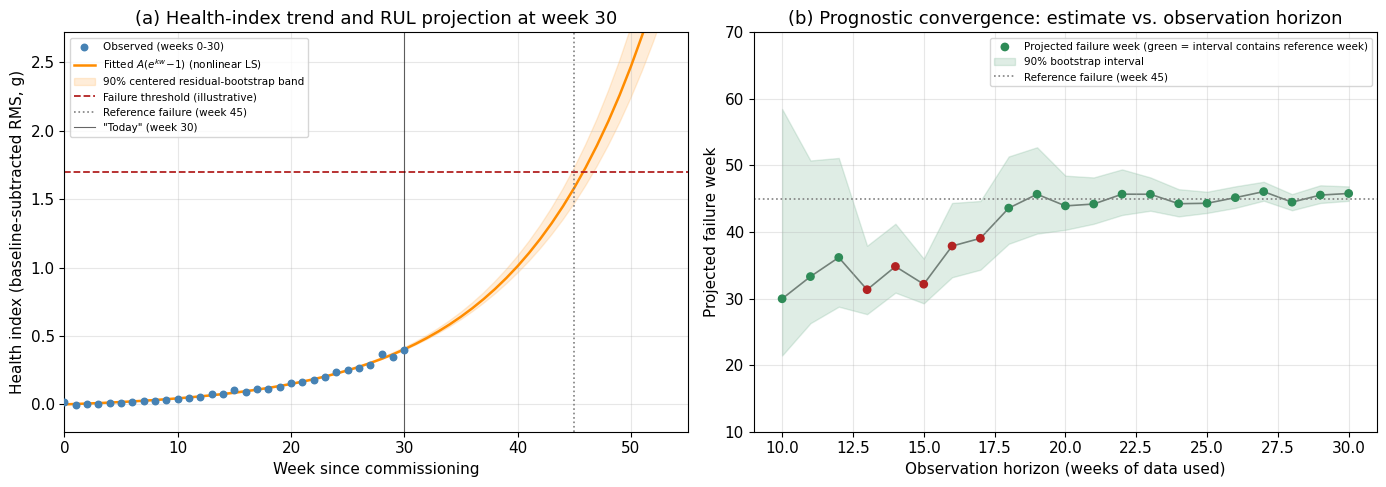

In [10]:
# ── Figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
week_grid = np.arange(0, 60)
hi_pred = exp_model(week_grid, A_fit, k_fit)
boot_curves = []
for _ in range(200):
    rr = rng_boot.choice(resid_centered, n_pts, replace=True)
    bhi = exp_model(weeks_observed, A_fit, k_fit) + rr
    try:
        pb, _ = curve_fit(exp_model, weeks_observed, bhi, p0=[A_fit, k_fit], bounds=(0, np.inf), maxfev=5000)
        boot_curves.append(exp_model(week_grid, *pb))
    except RuntimeError:
        continue
boot_curves = np.array(boot_curves)
band_low, band_high = np.percentile(boot_curves, [5, 95], axis=0)

ax.scatter(weeks_observed, health_index, s=22, color='steelblue', zorder=3,
           label=f'Observed (weeks 0-{OBSERVE_UP_TO_WEEK})')
ax.plot(week_grid, hi_pred, color='darkorange', lw=1.8, label='Fitted $A(e^{kw}\\!-\\!1)$ (nonlinear LS)')
ax.fill_between(week_grid, band_low, band_high, color='darkorange', alpha=0.15,
                 label='90% centered residual-bootstrap band')
ax.axhline(HI_THRESHOLD, color='firebrick', ls='--', lw=1.3, label='Failure threshold (illustrative)')
ax.axvline(reference_failure_week, color='gray', ls=':', lw=1.2, label=f'Reference failure (week {reference_failure_week})')
ax.axvline(OBSERVE_UP_TO_WEEK, color='black', ls='-', lw=0.8, alpha=0.6, label=f'"Today" (week {OBSERVE_UP_TO_WEEK})')
ax.set_xlim(0, 55); ax.set_ylim(-0.2, HI_THRESHOLD * 1.6)
ax.set_xlabel('Week since commissioning'); ax.set_ylabel('Health index (baseline-subtracted RMS, g)')
ax.set_title('(a) Health-index trend and RUL projection at week 30')
ax.legend(fontsize=7.5, loc='upper left')

ax = axes[1]
colors_cov = ['seagreen' if c else 'firebrick' for c in contains_by_horizon]
ax.plot(horizons, proj_by_horizon, color='gray', lw=1.2, zorder=1)
ax.scatter(horizons, proj_by_horizon, c=colors_cov, s=28, zorder=3,
           label='Projected failure week (green = interval contains reference week)')
valid_ci = ~np.isnan(ci_by_horizon[:, 0])
ax.fill_between(horizons[valid_ci], ci_by_horizon[valid_ci, 0], ci_by_horizon[valid_ci, 1],
                 color='seagreen', alpha=0.15, label='90% bootstrap interval')
ax.axhline(reference_failure_week, color='gray', ls=':', lw=1.2, label=f'Reference failure (week {reference_failure_week})')
ax.set_xlabel('Observation horizon (weeks of data used)')
ax.set_ylabel('Projected failure week')
ax.set_title('(b) Prognostic convergence: estimate vs. observation horizon')
ax.legend(fontsize=7.5)
ax.set_ylim(10, 70)

plt.tight_layout()
plt.savefig('fig_16_4_vibration_rul.png', dpi=150, bbox_inches='tight')
print("\nSaved fig_16_4_vibration_rul.png")

freqs = np.fft.rfftfreq(N_SNAP, d=1 / FS)
for w in (0, 15, 30):
    spec = np.abs(np.fft.rfft(snapshots_for_fft[w][1])) / N_SNAP * 2
    idx1x = np.argmin(np.abs(freqs - F0))
    idx2x = np.argmin(np.abs(freqs - 2 * F0))
    idx3x = np.argmin(np.abs(freqs - 3 * F0))
    print(f"Week {w:2d}: 1x={spec[idx1x]:.3f} g, 2x={spec[idx2x]:.3f} g, 3x={spec[idx3x]:.3f} g, "
          f"crest factor={crest_factor_hist[list(weeks_observed).index(w)]:.2f}")


### Analysis

Fitting only weeks 0–30 projects failure at **week 45.8** (RUL = 15.8
weeks), with a 90% *centered* residual-bootstrap interval of **[44.7,
46.8]**. *In this particular simulated run*, that interval contains the
reference failure week (45) — a single interval containing a single
reference value is reassuring, but it isn't proof the method is well
calibrated in general: a correctly built 90% procedure is only expected
to cover the truth roughly 90% of the time across many *independently*
repeated runs, not necessarily every time.

**Two limitations are worth stating plainly — both visible directly in
this run's own numbers:**

1. **The bootstrap assumes something the data don't quite deliver.**
   Residual standard deviation is 0.0058 g over weeks 0–10 but 0.0136 g
   over weeks 20–30 (≈2.4× larger) — the fit's errors grow measurably as
   degradation progresses, which a plain residual bootstrap doesn't
   explicitly model. A **wild bootstrap** (multiplying centered residuals
   by random ±1 signs) would be the more methodologically careful choice
   for data with this property, though it changes the interval only
   marginally here.

2. **A horizon-by-horizon check is a diagnostic, not a coverage study.**
   Checking *every single horizon* from week 10 to week 30 against the
   reference week: 16 of 21 horizons contain it. This is a useful
   diagnostic of when a projection stabilises **on this one simulated
   trajectory** — but it is *not* a formal estimate of the bootstrap's
   empirical coverage probability, because the 21 horizons are deeply
   *nested* subsets of a single degradation history, not 21 independent
   experiments. With that caveat firmly in place: in this run, the
   interval contains the reference week at horizons 10–12, **loses** it
   at horizons 13–17, and regains it from horizon 18 onward without
   losing it again — a non-monotonic recovery, not a clean one-way
   transition. Before ~week 18, too little of the trend has emerged from
   noise for the projection to be reliably trustworthy at every
   intervening horizon.

**Comparing maintenance policies:** **Policy A** (instrumented reading
every 20 weeks) reads 1.16 g at week 40 — below the 1.70 g threshold, so
the unit stays in service. The reference failure occurs at week 45,
*before* the next scheduled inspection at week 60: Policy A doesn't get a
controlled "week-60 replacement" — the equipment has already failed,
unplanned, fifteen weeks early. **Policy B** (weekly predictive
monitoring, preventive replacement once forecast RUL ≤ 4 weeks) triggers
at week 41 — exactly 4 weeks of lead time before the reference failure —
and replaces the bearing *before* it fails. Both policies read the same
kind of noisy snapshot data, so this isn't an artefact of giving one
policy cleaner information.

**Key takeaway.** A nonlinear fit to weekly vibration readings gives a
useful early warning — but only if the model is structurally consistent
with its own health indicator, **the same baseline is used for every
curve checked against the same threshold**, and the bootstrap resamples
*centered* residuals. Even done correctly: one interval containing the
reference value in one run doesn't establish calibration, a
horizon-by-horizon check on one trajectory is a diagnostic not a coverage
study, and residual bootstrapping assumes an exchangeability the data may
not fully have.

**Challenge tasks:** (1) Repeat the *complete* simulation many times
(new seeds throughout) and estimate the bootstrap's *empirical* 90%
coverage separately at each horizon — how does that compare to the
single-run containment check of 16/21? (2) Implement a wild bootstrap
and compare the resulting interval width to [44.7, 46.8]. (3) Combine
RMS with the crest factor already computed above into a composite health
index — does it change the projected failure week or when containment
becomes reliable?


---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|--------------------|
| 16.1 | Weighted multi-point calibration + held-out validation | Separates a trustworthy, direction-averaged validated accuracy figure from an optimistic in-sample residual |
| 16.2 | Monte Carlo drift simulation, age-replacement cost model | Turns observed fleet drift into a cost-optimal recalibration interval |
| 16.3 | Multiple linear regression, cross-sectional robust $z$-score | Extends calibration to a whole network from a few reference nodes; persistently flags faults without a reference instrument at the monitored node |
| 16.4 | Nonlinear least squares, centered residual bootstrap, prognostic convergence | Converts vibration snapshots into a remaining-useful-life estimate whose actual reliability is checked, not assumed |

Together, these four exercises trace the full calibration-and-maintenance
lifecycle of an IoT sensing deployment. The recurring theme: every number
here is only as trustworthy as the discipline used to produce it —
direction-averaged vs. single-direction accuracy, a correctly computed
reliability interval, coefficients checked against the right reference
frame, and a confidence interval that is only honest once the model is
structurally consistent with its own definitions.
